In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("genz_social_media_usage_1M.csv")

In [7]:
df.head(2)

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,19,Male,Australia,2.658617,Snapchat,4,Education,29.222443,0,6.705830,Medium,15.779443
1,16,Female,USA,5.685387,Twitter,3,Socializing,32.464726,1,6.633111,High,47.714864


In [6]:
def loop_nulls(df):
    # .items() iterates through (column_name, Series) pairs
    for column_name, data in df.items():
        null_count = data.isnull().sum()
        if null_count > 0:
            print(f"Column '{column_name}' has {null_count} null values.")
        else:
            print(f"Column '{column_name}' is clean!")

loop_nulls(df)

Column 'age' is clean!
Column 'gender' is clean!
Column 'country' is clean!
Column 'daily_usage_hours' is clean!
Column 'primary_platform' is clean!
Column 'num_platforms_used' is clean!
Column 'purpose' is clean!
Column 'avg_session_minutes' is clean!
Column 'night_usage' is clean!
Column 'mental_health_score' is clean!
Column 'addiction_level' is clean!
Column 'screen_time_before_sleep' is clean!


In [7]:
df = df.dropna(subset=['daily_usage_hours', 'mental_health_score'])
print(df[['daily_usage_hours', 'mental_health_score']].describe())

       daily_usage_hours  mental_health_score
count     1000000.000000       1000000.000000
mean            3.514998             7.170671
std             1.468771             1.503885
min             0.500000             1.000000
25%             2.493985             6.147371
50%             3.503302             7.198098
75%             4.513016             8.243818
max            10.000000            10.000000


In [16]:
df = df.dropna(subset=['daily_usage_hours', 'mental_health_score'])
print(df[['daily_usage_hours', 'mental_health_score']].describe())

       daily_usage_hours  mental_health_score
count     1000000.000000       1000000.000000
mean            3.514998             7.170671
std             1.468771             1.503885
min             0.500000             1.000000
25%             2.493985             6.147371
50%             3.503302             7.198098
75%             4.513016             8.243818
max            10.000000            10.000000


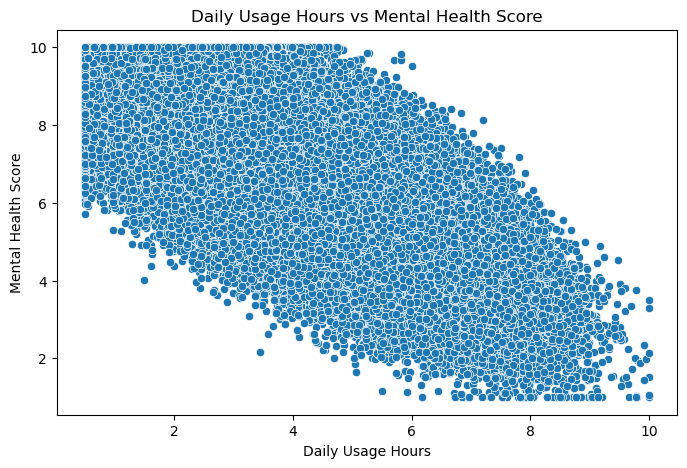

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='daily_usage_hours',y='mental_health_score', data=df)
plt.title("Daily Usage Hours vs Mental Health Score")
plt.xlabel("Daily Usage Hours")
plt.ylabel("Mental Health Score")

plt.show()

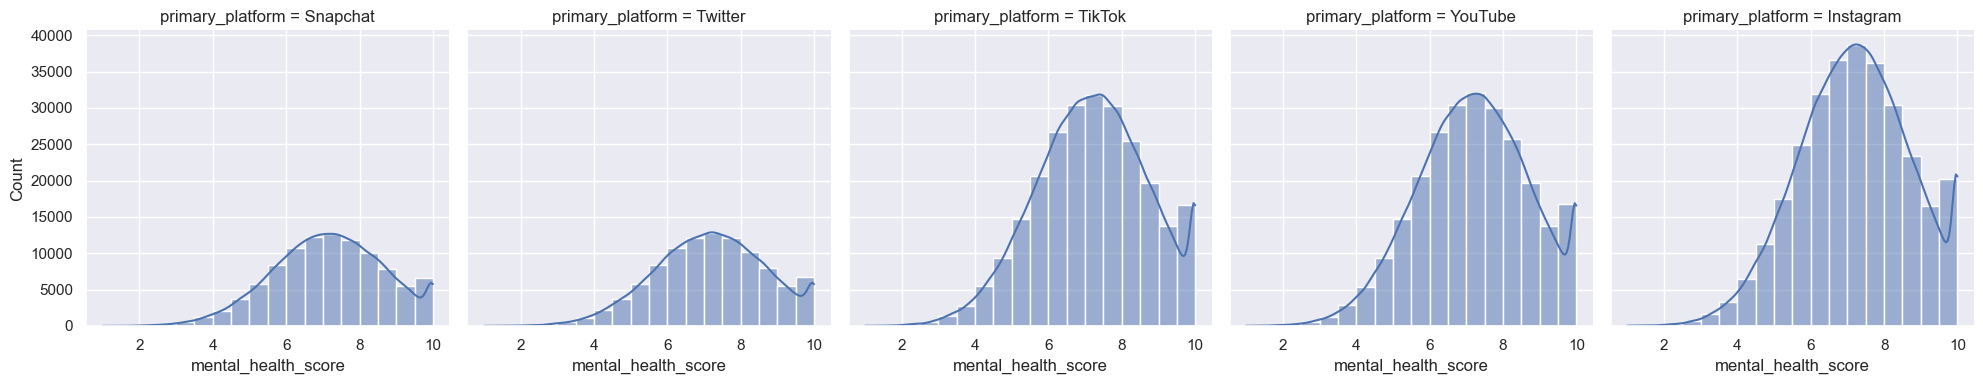

In [29]:
sns.set_theme(style="darkgrid")

g = sns.displot(
    df, 
    x="mental_health_score",
    col="primary_platform",   
    binwidth=0.5, 
    height=4, 
    facet_kws=dict(margin_titles=True),
    kde=True
)
plt.show()

In [31]:
night_users = df[df['night_usage'] == 1]['mental_health_score']
day_users = df[df['night_usage'] == 0]['mental_health_score']

# 2. Calculating means
print(f"Mean Score (Day Users): {day_users.mean():.2f}")
print(f"Mean Score (Night Users): {night_users.mean():.2f}")

# 3. Performing Independent T-Test
t_stat, p_val = stats.ttest_ind(day_users, night_users)
print(f"P-value: {p_val}")

Mean Score (Day Users): 7.17
Mean Score (Night Users): 7.17
P-value: 0.9011815888427852


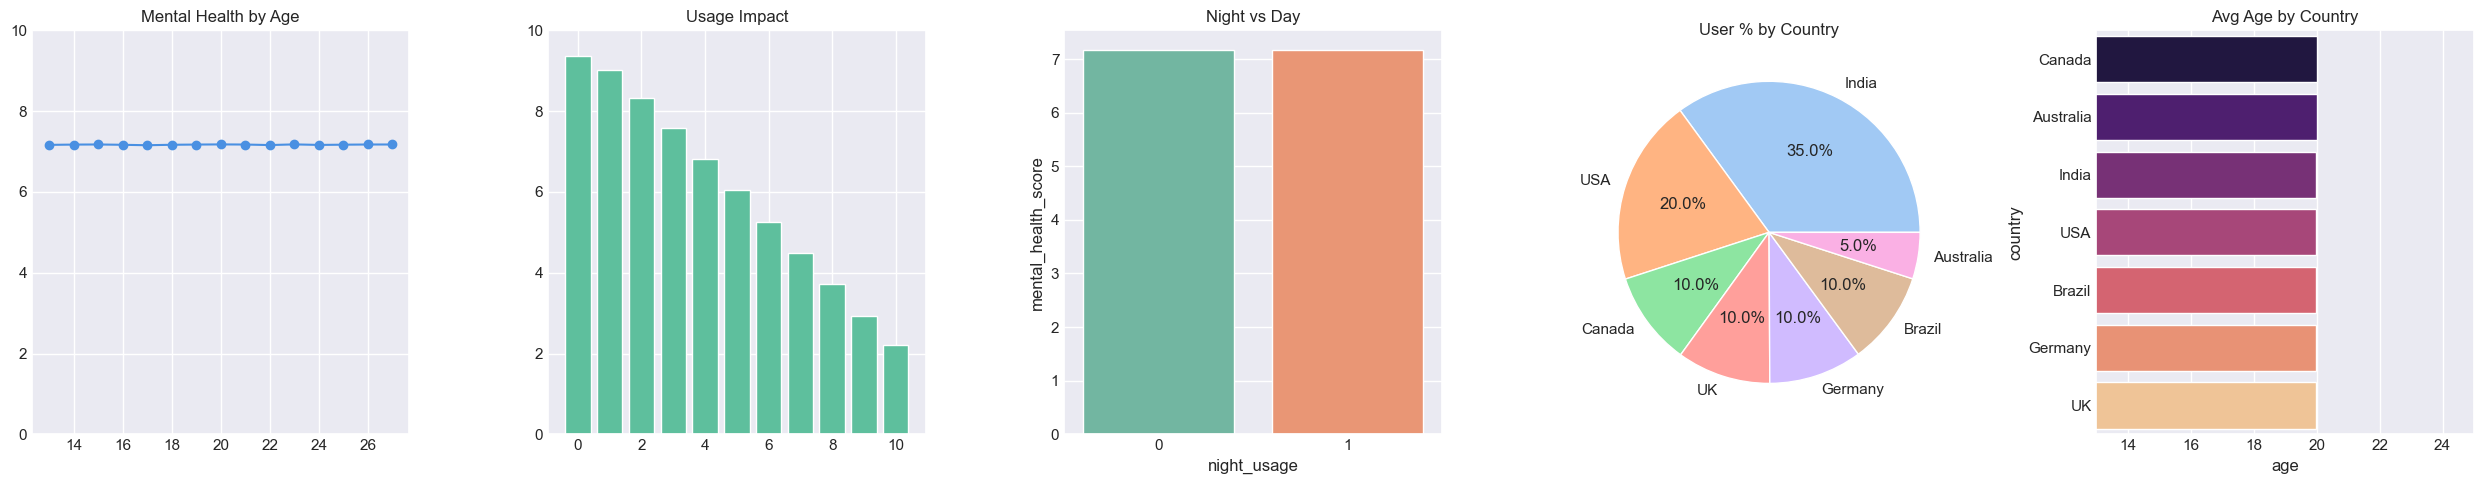

In [46]:
# 1. Prepare Data
df['usage_rounded'] = df['daily_usage_hours'].round()
age_summary = df.groupby('age')['mental_health_score'].mean().reset_index()
usage_summary = df.groupby('usage_rounded')['mental_health_score'].mean().reset_index()
country_counts = df['country'].value_counts()
country_age_summary = df.groupby('country')['age'].mean().sort_values(ascending=False).reset_index()

# 2. Setup Subplots
plt.style.use('_mpl-gallery')
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(25, 5))

# --- Plot 1: Age Trend ---
ax1.plot(age_summary['age'], age_summary['mental_health_score'], marker='o', color='#4a90e2')
ax1.set_title('Mental Health by Age')
ax1.set(ylim=(0, 10))

# --- Plot 2: Usage Impact ---
ax2.bar(usage_summary['usage_rounded'], usage_summary['mental_health_score'], color='#5ebf9d')
ax2.set_title('Usage Impact')
ax2.set(ylim=(0, 10))

# --- Plot 3: Night Usage ---
sns.barplot(ax=ax3, x='night_usage', y='mental_health_score', data=df, palette='Set2', hue='night_usage')
ax3.set_title('Night vs Day')
# Safety check for legend
if ax3.get_legend() is not None:
    ax3.get_legend().remove()

# --- Plot 4: Country Distribution ---
ax4.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
ax4.set_title('User % by Country')

# --- Plot 5: Avg Age by Country ---
sns.barplot(ax=ax5, x='age', y='country', data=country_age_summary, palette='magma', hue='country')
ax5.set_title('Avg Age by Country')
ax5.set_xlim(13, 25)
# Safety check for legend
if ax5.get_legend() is not None:
    ax5.get_legend().remove()

plt.tight_layout()
plt.show()

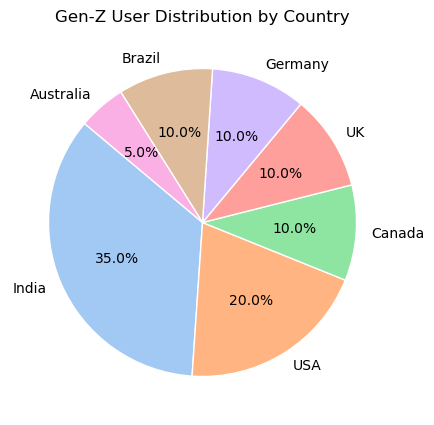

In [8]:
country_counts = df['country'].value_counts()

# 2. Create the Circle (Pie Chart)
plt.figure(figsize=(5, 5))
plt.pie(
    country_counts, 
    labels=country_counts.index, 
    autopct='%1.1f%%',       # Shows the percentage on the slice
    startangle=140,          # Rotates the start of the chart
    colors=sns.color_palette('pastel'),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1} # Adds white lines between slices
)

plt.title('Gen-Z User Distribution by Country')
plt.show()

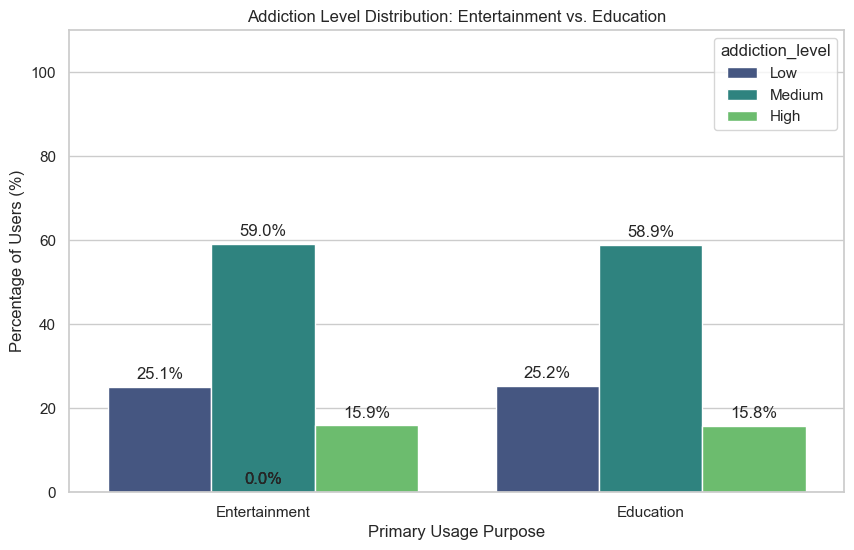

In [10]:
ct = pd.crosstab(df['purpose'], df['addiction_level'], normalize='index') * 100

# 2. Filter for the comparison between Entertainment and Education
comparison = ct.loc[['Entertainment', 'Education']]

# 3. Reshape the data for Seaborn plotting
plot_df = comparison.reset_index().melt(id_vars='purpose', var_name='addiction_level', value_name='percentage')

# 4. Visualization
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Plotting the grouped bar chart
ax = sns.barplot(
    data=plot_df, 
    x='purpose', 
    y='percentage', 
    hue='addiction_level',
    hue_order=['Low', 'Medium', 'High'], # Logical ordering
    palette='viridis'
)

# Add labels on top of bars for readability
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), 
                textcoords='offset points')

plt.title('Addiction Level Distribution: Entertainment vs. Education')
plt.ylabel('Percentage of Users (%)')
plt.xlabel('Primary Usage Purpose')
plt.ylim(0, 110) 
plt.show()

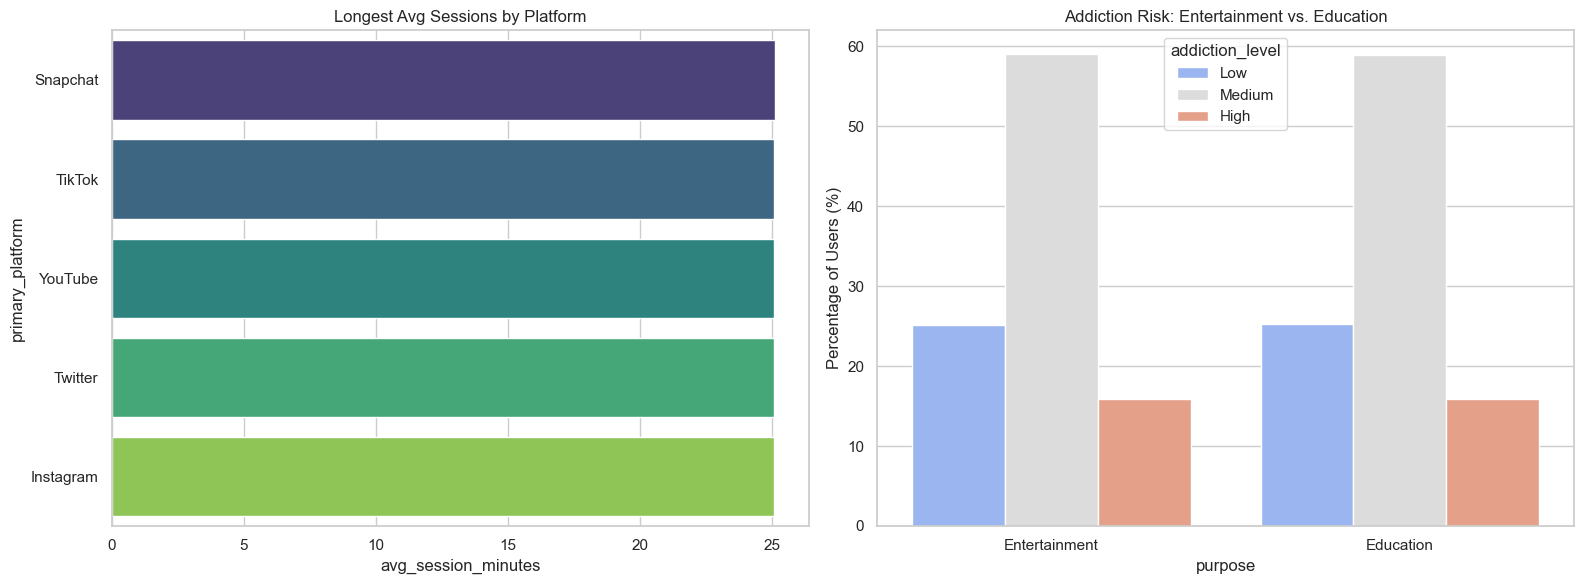

In [12]:
fig, (ax_p1, ax_p2) = plt.subplots(1, 2, figsize=(16, 6))

# Platform Session Duration
platform_session = df.groupby('primary_platform')['avg_session_minutes'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=platform_session, x='avg_session_minutes', y='primary_platform', ax=ax_p1, palette='viridis', hue='primary_platform')
ax_p1.set_title('Longest Avg Sessions by Platform')
if ax_p1.get_legend(): ax_p1.get_legend().remove()

# Addiction Levels: Entertainment vs Education
# Normalize percentages to compare group risks fairly
ct = pd.crosstab(df['purpose'], df['addiction_level'], normalize='index') * 100
comparison = ct.loc[['Entertainment', 'Education']].reset_index().melt(id_vars='purpose', var_name='addiction_level', value_name='percentage')

sns.barplot(data=comparison, x='purpose', y='percentage', hue='addiction_level', hue_order=['Low', 'Medium', 'High'], ax=ax_p2, palette='coolwarm')
ax_p2.set_title('Addiction Risk: Entertainment vs. Education')
ax_p2.set_ylabel('Percentage of Users (%)')

plt.tight_layout()
plt.show()